In [7]:
import geopandas as gpd

fp = "../../data/cantons/swissBOUNDARIES3D_1_3_TLM_KANTONSGEBIET.shp"

# Read file using gpd.read_file()
data = gpd.read_file(fp)
type(data)


geopandas.geodataframe.GeoDataFrame

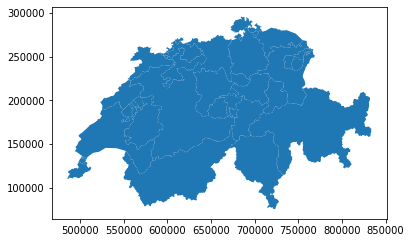

In [8]:
data.plot()

In [9]:
matplotlib inline

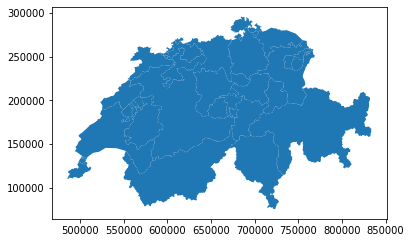

In [10]:
data.plot()

In [11]:
data.head(1)

,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
0,{0B2364ED-49E0-4D53-A33C-C684DD530B57},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,18,NaN,710530.0,0,Graubünden,197888.0,"POLYGON Z ((709776.070 185645.951 3062.876, 70..."


In [12]:
print(data['geometry'].head(1).exterior)

0    LINEARRING Z (709776.070 185645.951 3062.876, ...
dtype: geometry


In [13]:
data['geometry'].head(1).area

0    7.105217e+09
dtype: float64

In [14]:
selection=data.loc[data['NAME']=='Vaud']
selection


,UUID,DATUM_AEND,DATUM_ERST,ERSTELL_J,ERSTELL_M,REVISION_J,REVISION_M,GRUND_AEND,HERKUNFT,HERKUNFT_J,...,OBJEKTART,REVISION_Q,ICC,KANTONSNUM,SEE_FLAECH,KANTONSFLA,KT_TEIL,NAME,EINWOHNERZ,geometry
3,{921DFEF2-6D91-4CB8-9CFC-2A831C412020},2018-11-22,2012-10-26,2012,10,2019,1,Verbessert,AV,2019,...,Kanton,2018_Aufbau,CH,22,39097.0,321201.0,1,Vaud,793129.0,"POLYGON Z ((549756.794 189303.160 429.247, 548..."
26,{DAD81A01-85E7-4FFC-B0C9-B2359730300E},2015-12-08,2012-10-26,2012,10,2019,1,Verbessert,AV,2015,...,Kanton,2018_Aufbau,CH,22,NaN,NaN,2,Vaud,NaN,"POLYGON Z ((569696.161 203238.821 428.943, 569..."


In [18]:
for idx,row in selection.iterrows():
    area=row['geometry'].area
    print("The geometry area at {0} is {1}".format(idx,area))

The geometry area at 3 is 3118536618.903036
The geometry area at 26 is 93463290.32157156


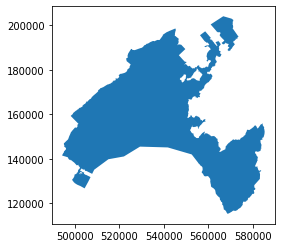

In [19]:
selection.plot()

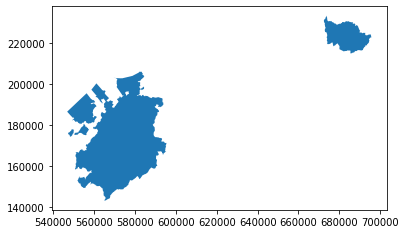

In [20]:
zugAndFribourg=data.loc[(data['NAME']=='Zug') | (data['NAME']=='Fribourg')]
zugAndFribourg.plot()

In [24]:

for idx,row in zugAndFribourg.iterrows():
    dist=row['geometry'].distance(data.loc[6]['geometry'])
    print("distance from {0} to {1} is {2}".format(data.loc[8]['NAME'],row['NAME'],dist))

distance from Luzern to Fribourg is 89285.81765415004
distance from Luzern to Zug is 0.0
distance from Luzern to Fribourg is 120366.3759727847
distance from Luzern to Fribourg is 128313.15985575122
distance from Luzern to Fribourg is 135083.44823267878
distance from Luzern to Fribourg is 95400.12430371482
distance from Luzern to Fribourg is 118589.42796294784


In [25]:
newData=gpd.GeoDataFrame()
newData['geometry']=None

data['center']=None

for idx,row in data.iterrows():
    center=row['geometry'].centroid
    data.loc[idx,'center']=center

In [26]:
df=gpd.GeoDataFrame(data['center'])
df
conversion={'center':'geometry'}
df.rename(columns=conversion)

,geometry
0,POINT (767575.0244501946 169561.5515886946)
1,POINT (614277.2987648115 185601.5741448295)
2,POINT (612816.6401953455 117581.908002399)
3,POINT (539303.7917365739 156760.3369243431)
4,POINT (705582.446308137 128055.1089343966)
5,POINT (739058.4421031841 233039.9063328989)
6,POINT (691804.3897484293 252035.1222239229)
7,POINT (573827.5419753399 173065.4281091813)
8,POINT (651010.0992641809 213189.1664508271)
9,POINT (654217.6257056012 251244.1736071813)


In [27]:
df.crs=data.crs

In [28]:
df.crs

<Projected CRS: EPSG:21781>
Name: CH1903 / LV03
Axis Info [cartesian]:
- Y[east]: Easting (metre)
- X[north]: Northing (metre)
Area of Use:
- name: Europe - Liechtenstein and Switzerland
- bounds: (5.96, 45.82, 10.49, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1903M
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [29]:
df=df.set_geometry('center')

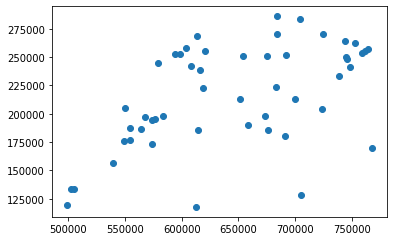

In [30]:
df.plot()

In [31]:
df.to_file('swissCenters.shp')